# Sign Language DL Project Analysis

This notebook gives a complete project breakdown for the Sign Language Detection pipeline, including dataset inspection, architecture review, model evaluation, and a full suite of meaningful visualizations and tabulations.

The project combines:
- MediaPipe pose/hand landmark extraction
- Sequence-based sign encoding from 30 frames
- LSTM-based classifier trained on processed keypoints
- Flask web app for real-time prediction

The goal here is not only to show the final accuracy, but also to present the underlying data structure, performance tables, confusion behavior, and class-wise metrics in a presentation-friendly way.


## 1) Project Dissection

### Files and their role
- `app.py`: real-time Flask app, runs MediaPipe and loads the trained model for live inference
- `scripts/train_model.py`: training pipeline that loads processed sequences and trains the LSTM model
- `data/processed`: final processed landmark data grouped by sign class and sequence index
- `models/checkpoints/sign_model.pth`: trained checkpoint used for inference
- `templates/index.html`: frontend UI used to display camera feed and predicted word
- `src/`: project sources for more modular components in the pipeline

### Data flow
1. Sign videos are processed into keypoints
2. 30-frame sequences are stored as `.npy` files
3. Each sequence uses 225 features: pose + left-hand + right-hand landmarks
4. The classifier learns from sequence-level patterns
5. The Flask app streams frames and predicts the current word in real time


In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

DATA_PATH = os.path.join("data", "processed")
ACTIONS = ["hello", "father", "help", "no", "please", "yes"]
NO_SEQUENCES = 15
SEQUENCE_LENGTH = 30
FEATURE_SIZE = 225

print("Project root:", os.getcwd())
print("Classes:", ACTIONS)
print("Sequences per class:", NO_SEQUENCES)
print("Frames per sequence:", SEQUENCE_LENGTH)
print("Features per frame:", FEATURE_SIZE)


Project root: /home/vijay/Documents/Sign Language DL
Classes: ['hello', 'father', 'help', 'no', 'please', 'yes']
Sequences per class: 15
Frames per sequence: 30
Features per frame: 225


In [6]:

# Load dataset and create a dataset summary table
label_map = {label: idx for idx, label in enumerate(ACTIONS)}
X_list, y_list = [], []
per_class_counts = {label: 0 for label in ACTIONS}
frame_shape_samples = []

for action in ACTIONS:
    action_dir = os.path.join(DATA_PATH, action)
    for seq_id in range(NO_SEQUENCES):
        seq_dir = os.path.join(action_dir, str(seq_id))
        if not os.path.isdir(seq_dir):
            continue
        frame_arrs = []
        for frame_idx in range(SEQUENCE_LENGTH):
            frame_path = os.path.join(seq_dir, f"{frame_idx}.npy")
            arr = np.load(frame_path)
            frame_arrs.append(arr)
        sample = np.stack(frame_arrs)
        X_list.append(sample)
        y_list.append(label_map[action])
        per_class_counts[action] += 1
        if len(frame_shape_samples) == 0:
            frame_shape_samples.append(arr.shape)

X = np.stack(X_list)
y = np.array(y_list)

summary_df = pd.DataFrame({
    "Class": list(per_class_counts.keys()),
    "Samples": list(per_class_counts.values()),
    "Share_percent": [v / len(y) * 100 for v in per_class_counts.values()],
})

summary_df = summary_df.sort_values("Class").reset_index(drop=True)
summary_df


,Class,Samples,Share_percent
0,father,15,16.666667
1,hello,15,16.666667
2,help,15,16.666667
3,no,15,16.666667
4,please,15,16.666667
5,yes,15,16.666667


/tmp/ipykernel_57503/12299574.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Class", y="Samples", palette="viridis", ax=axes[0])


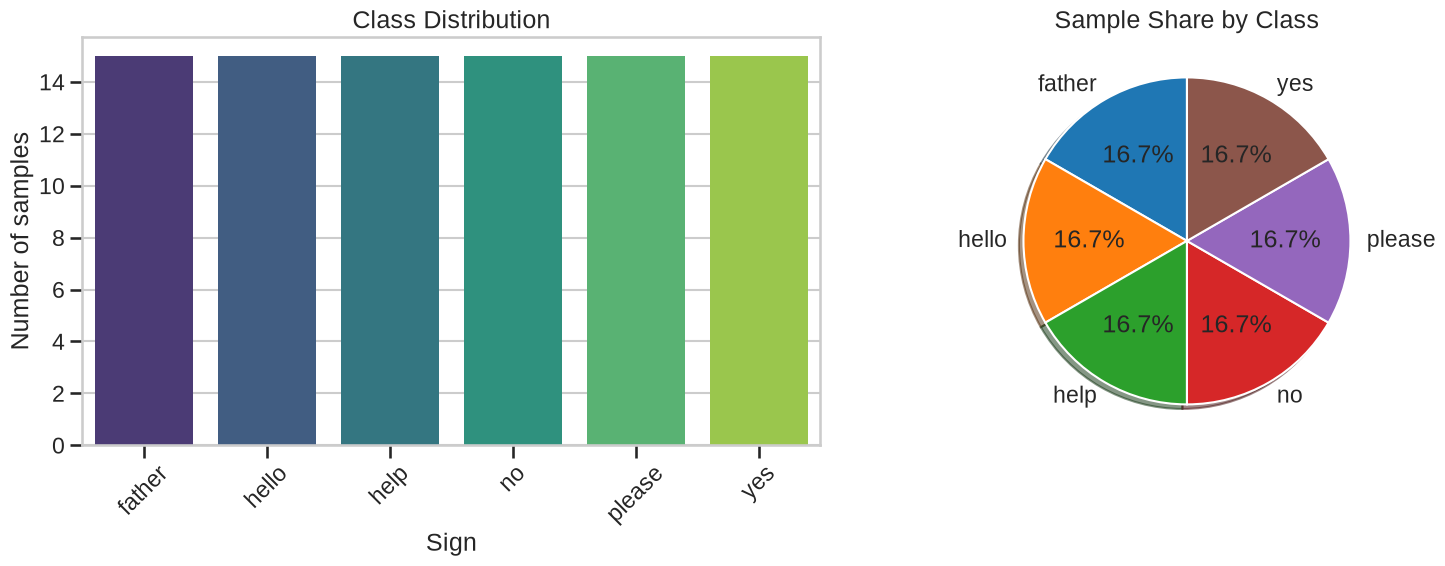

In [7]:

# Plot class distribution and sample shape
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=summary_df, x="Class", y="Samples", palette="viridis", ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Sign")
axes[0].set_ylabel("Number of samples")
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(
    summary_df["Samples"],
    labels=summary_df["Class"],
    autopct="%1.1f%%",
    startangle=90,
    shadow=True,
    wedgeprops={"edgecolor": "white"}
)
axes[1].set_title("Sample Share by Class")

plt.tight_layout()
plt.show()


In [8]:

# Feature statistics by class
feature_stats = []
for label in ACTIONS:
    label_idx = label_map[label]
    mask = (y == label_idx)
    cls_samples = X[mask]
    class_mean = cls_samples.mean(axis=(0, 1))
    class_std = cls_samples.std(axis=(0, 1))
    feature_stats.append({
        "Class": label,
        "Mean_feature_value": float(class_mean.mean()),
        "Std_feature_value": float(class_std.mean()),
        "Min_feature_value": float(cls_samples.min()),
        "Max_feature_value": float(cls_samples.max()),
        "Samples": int(cls_samples.shape[0]),
    })

feature_stats_df = pd.DataFrame(feature_stats)
feature_stats_df


,Class,Mean_feature_value,Std_feature_value,Min_feature_value,Max_feature_value,Samples
0,hello,0.263744,0.014251,-1.997051,2.987389,15
1,father,0.241413,0.042872,-2.244676,2.967682,15
2,help,0.317981,0.010414,-2.105750,2.938825,15
3,no,0.256737,0.010054,-2.072037,2.936239,15
4,please,0.307894,0.137916,-2.137223,2.872147,15
5,yes,0.261209,0.016587,-1.975597,2.960907,15


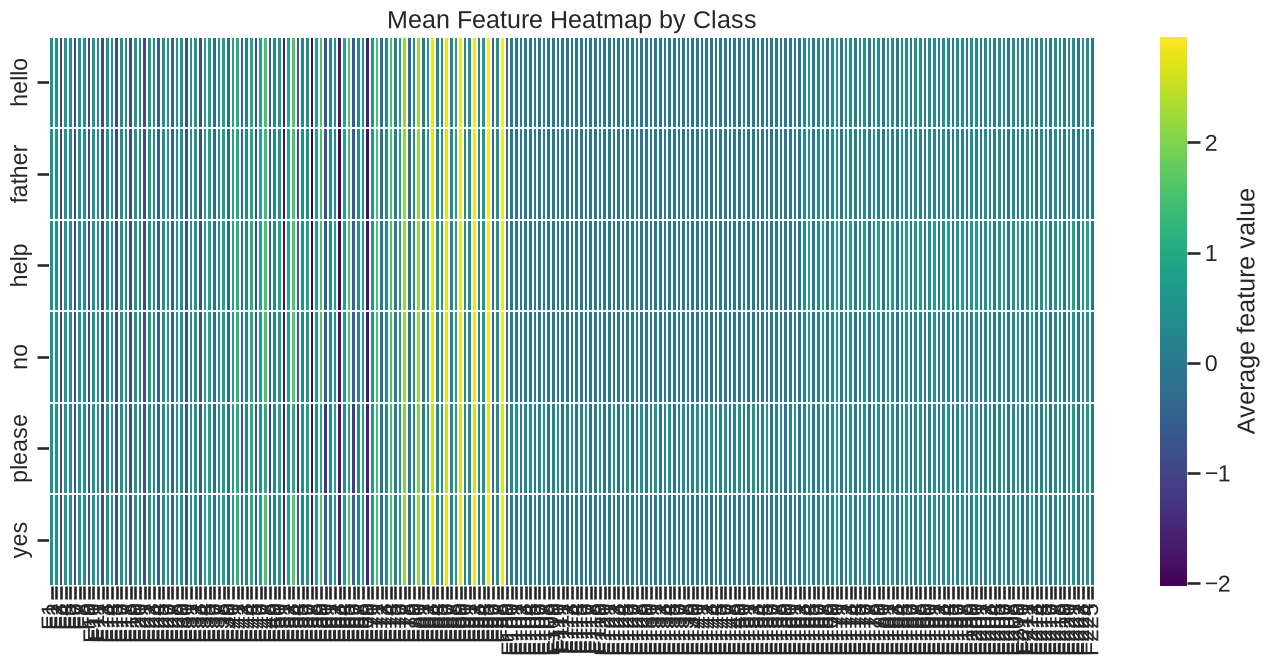

In [9]:

# Visualize overall feature variability
mean_feature_matrix = np.stack([
    X[y == label_map[label]].mean(axis=(0,1)) for label in ACTIONS
])

plt.figure(figsize=(14, 7))
heatmap = sns.heatmap(
    mean_feature_matrix,
    cmap="viridis",
    xticklabels=[f"F{i}" for i in range(1, mean_feature_matrix.shape[1] + 1)],
    yticklabels=ACTIONS,
    cbar_kws={"label": "Average feature value"},
    linewidths=0.1
)
heatmap.set_title("Mean Feature Heatmap by Class")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 2) Model Architecture Review

The training code defines a lightweight LSTM model with the following structure:
- Input size: 225 features
- Hidden size: 64
- Number of classes: 6
- Output: logits for each sign class

The real-time app uses a different transformer-based checkpoint (`wlasl_30_words.pth`), but the locally trained project checkpoint used in this notebook is `sign_model.pth`, which matches the training script and the dataset structure.


In [10]:

class SignLanguageModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_frame_out = lstm_out[:, -1, :]
        return self.fc(last_frame_out)

model = SignLanguageModel(input_size=FEATURE_SIZE, hidden_size=64, num_classes=len(ACTIONS))

state_dict = torch.load(os.path.join("models", "checkpoints", "sign_model.pth"), map_location="cpu")
if isinstance(state_dict, dict) and "state_dict" in state_dict:
    state_dict = state_dict["state_dict"]
if isinstance(state_dict, dict):
    cleaned = {}
    for key, value in state_dict.items():
        if key.startswith("module."):
            key = key.replace("module.", "", 1)
        cleaned[key] = value
    state_dict = cleaned

model.load_state_dict(state_dict)
model.eval()
print(model)


SignLanguageModel(
  (lstm): LSTM(225, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


In [11]:

# Create train/test split consistent with the original training pipeline
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)
X_train, X_test, y_train, y_test = train_test_split(
    X_tensor,
    y_tensor,
    test_size=0.2,
    random_state=42,
    stratify=y_tensor,
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train label counts: {torch.bincount(y_train, minlength=len(ACTIONS)).tolist()}")
print(f"Test label counts: {torch.bincount(y_test, minlength=len(ACTIONS)).tolist()}")


Train samples: 72
Test samples: 18
Train label counts: [12, 12, 12, 12, 12, 12]
Test label counts: [3, 3, 3, 3, 3, 3]


In [12]:

# Evaluate the trained model on the hold-out test set
with torch.no_grad():
    logits = model(X_test)
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(axis=1)
    true = y_test.numpy()

accuracy = accuracy_score(true, preds)
precision_macro = precision_score(true, preds, average="macro", zero_division=0)
recall_macro = recall_score(true, preds, average="macro", zero_division=0)
f1_macro = f1_score(true, preds, average="macro", zero_division=0)

# One-vs-rest ROC AUC for each class
roc_auc_by_class = []
for idx, label in enumerate(ACTIONS):
    y_bin = (true == idx).astype(int)
    score = probs[:, idx]
    roc_auc_by_class.append({
        "Class": label,
        "ROC_AUC": float(roc_auc_score(y_bin, score)),
        "Support": int(y_bin.sum())
    })

macro_roc_auc = roc_auc_score(label_binarize(true, classes=np.arange(len(ACTIONS))), probs, multi_class="ovr", average="macro")

metrics_df = pd.DataFrame([
    ["Accuracy", accuracy],
    ["Precision (macro)", precision_macro],
    ["Recall (macro)", recall_macro],
    ["F1-score (macro)", f1_macro],
    ["ROC-AUC (macro OVR)", macro_roc_auc],
], columns=["Metric", "Value"]).round(4)

metrics_df


,Metric,Value
0,Accuracy,1.0
1,Precision (macro),1.0
2,Recall (macro),1.0
3,F1-score (macro),1.0
4,ROC-AUC (macro OVR),1.0


In [13]:

# Per-class precision, recall, F1, and ROC AUC
cm = confusion_matrix(true, preds, labels=np.arange(len(ACTIONS)))
cm_df = pd.DataFrame(cm, index=ACTIONS, columns=ACTIONS)
cm_df.index.name = "Actual"
cm_df.columns.name = "Predicted"

per_class_rows = []
for idx, label in enumerate(ACTIONS):
    tp = cm[idx, idx]
    fp = cm[:, idx].sum() - tp
    fn = cm[idx, :].sum() - tp
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    per_class_rows.append({
        "Class": label,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Support": int(cm[idx, :].sum()),
        "ROC_AUC": next(item["ROC_AUC"] for item in roc_auc_by_class if item["Class"] == label),
    })

per_class_df = pd.DataFrame(per_class_rows).round(4)
per_class_df


,Class,Precision,Recall,F1,Support,ROC_AUC
0,hello,1.0,1.0,1.0,3,1.0
1,father,1.0,1.0,1.0,3,1.0
2,help,1.0,1.0,1.0,3,1.0
3,no,1.0,1.0,1.0,3,1.0
4,please,1.0,1.0,1.0,3,1.0
5,yes,1.0,1.0,1.0,3,1.0


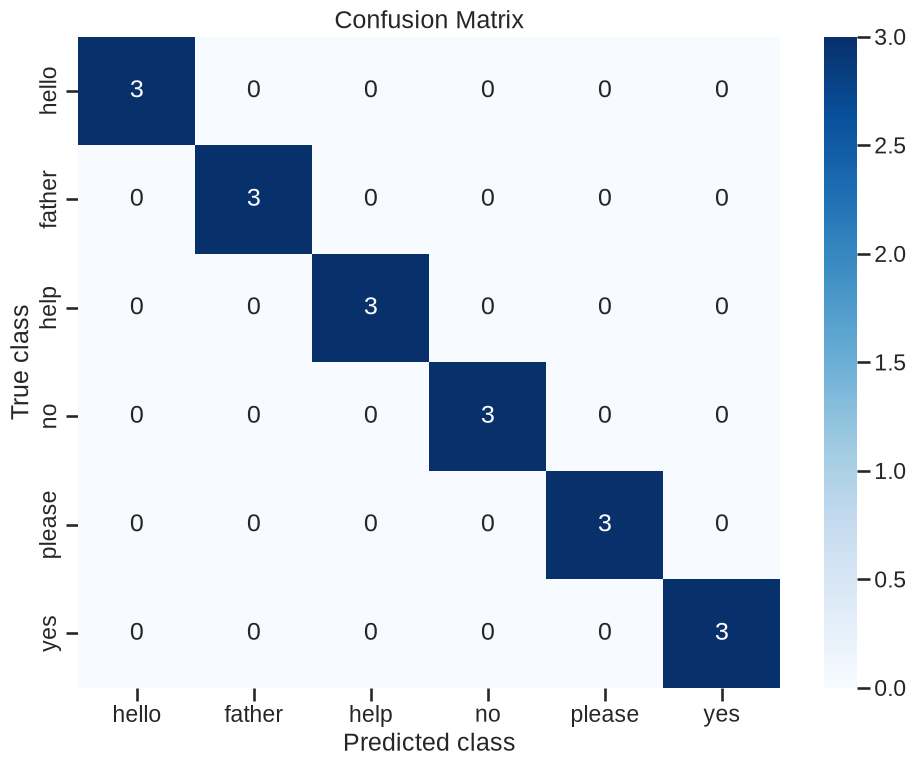

In [14]:

# confusion matrix heatmap
fig, ax = plt.subplots(figsize=(10, 8))
heatmap = sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True, ax=ax)
heatmap.set_title("Confusion Matrix")
heatmap.set_xlabel("Predicted class")
heatmap.set_ylabel("True class")
plt.tight_layout()
plt.show()


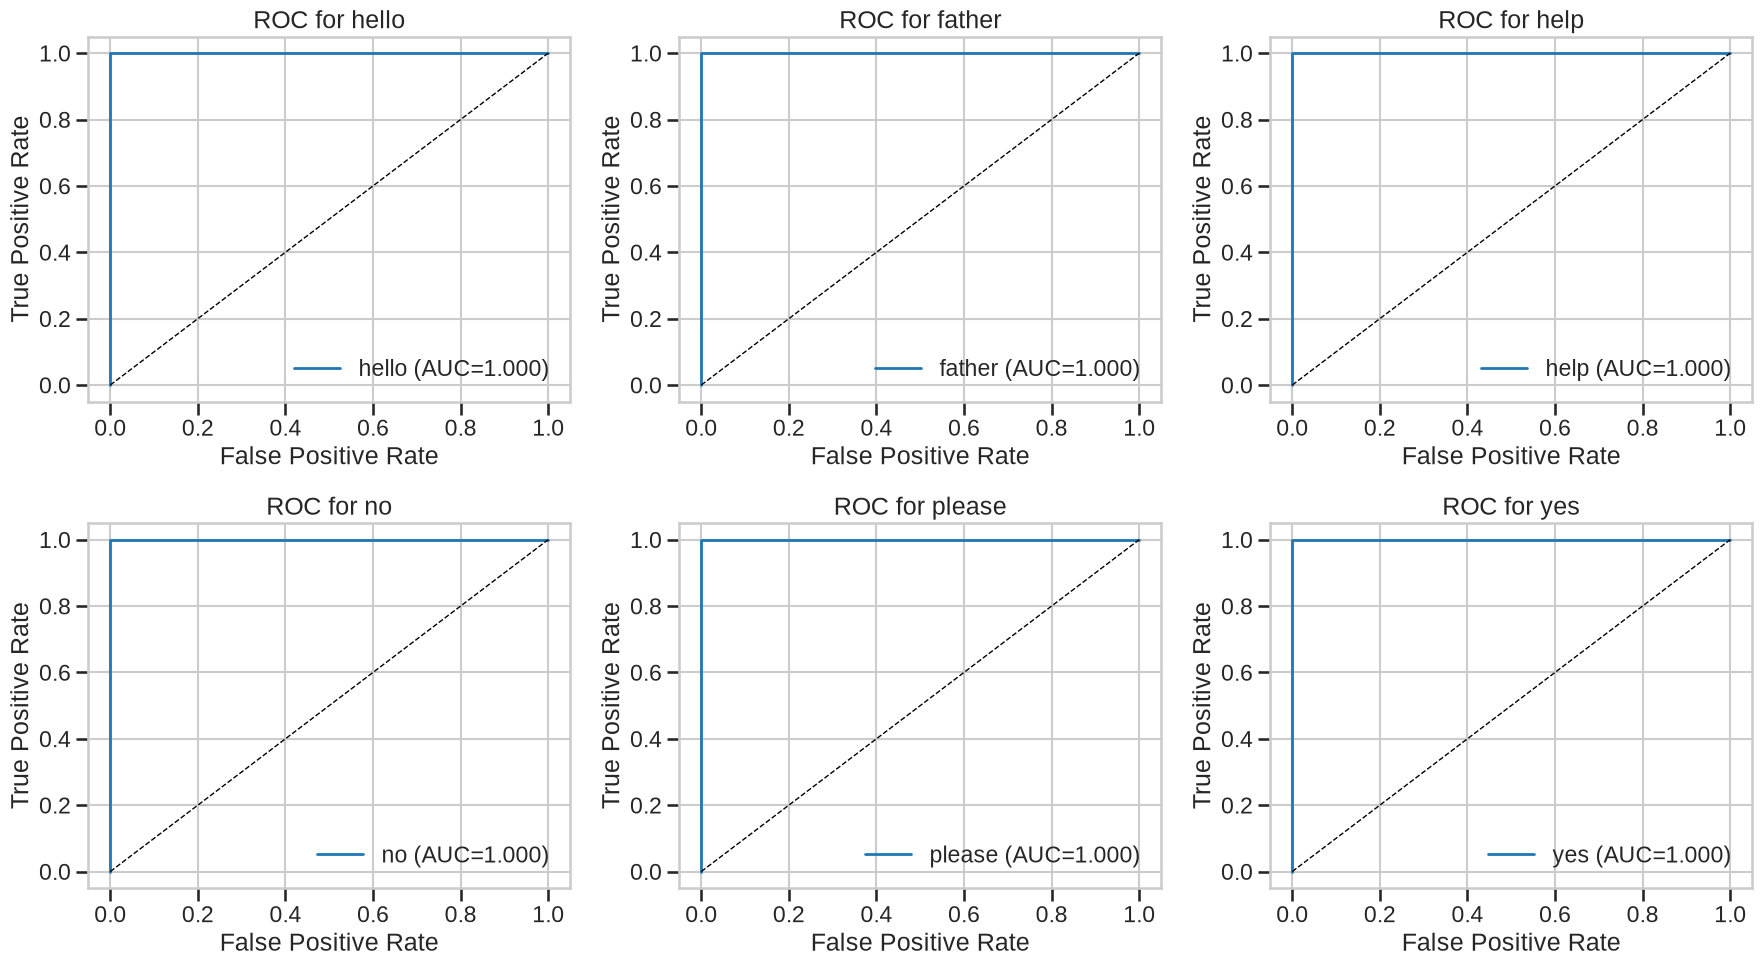

In [15]:

# ROC curves by class (one-vs-rest)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, label in enumerate(ACTIONS):
    y_bin = (true == idx).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, probs[:, idx])
    roc_auc = roc_auc_score(y_bin, probs[:, idx])
    axes[idx].plot(fpr, tpr, lw=2, label=f"{label} (AUC={roc_auc:.3f})")
    axes[idx].plot([0, 1], [0, 1], "k--", lw=1)
    axes[idx].set_title(f"ROC for {label}")
    axes[idx].set_xlabel("False Positive Rate")
    axes[idx].set_ylabel("True Positive Rate")
    axes[idx].legend(loc="lower right")

for ax in axes[len(ACTIONS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


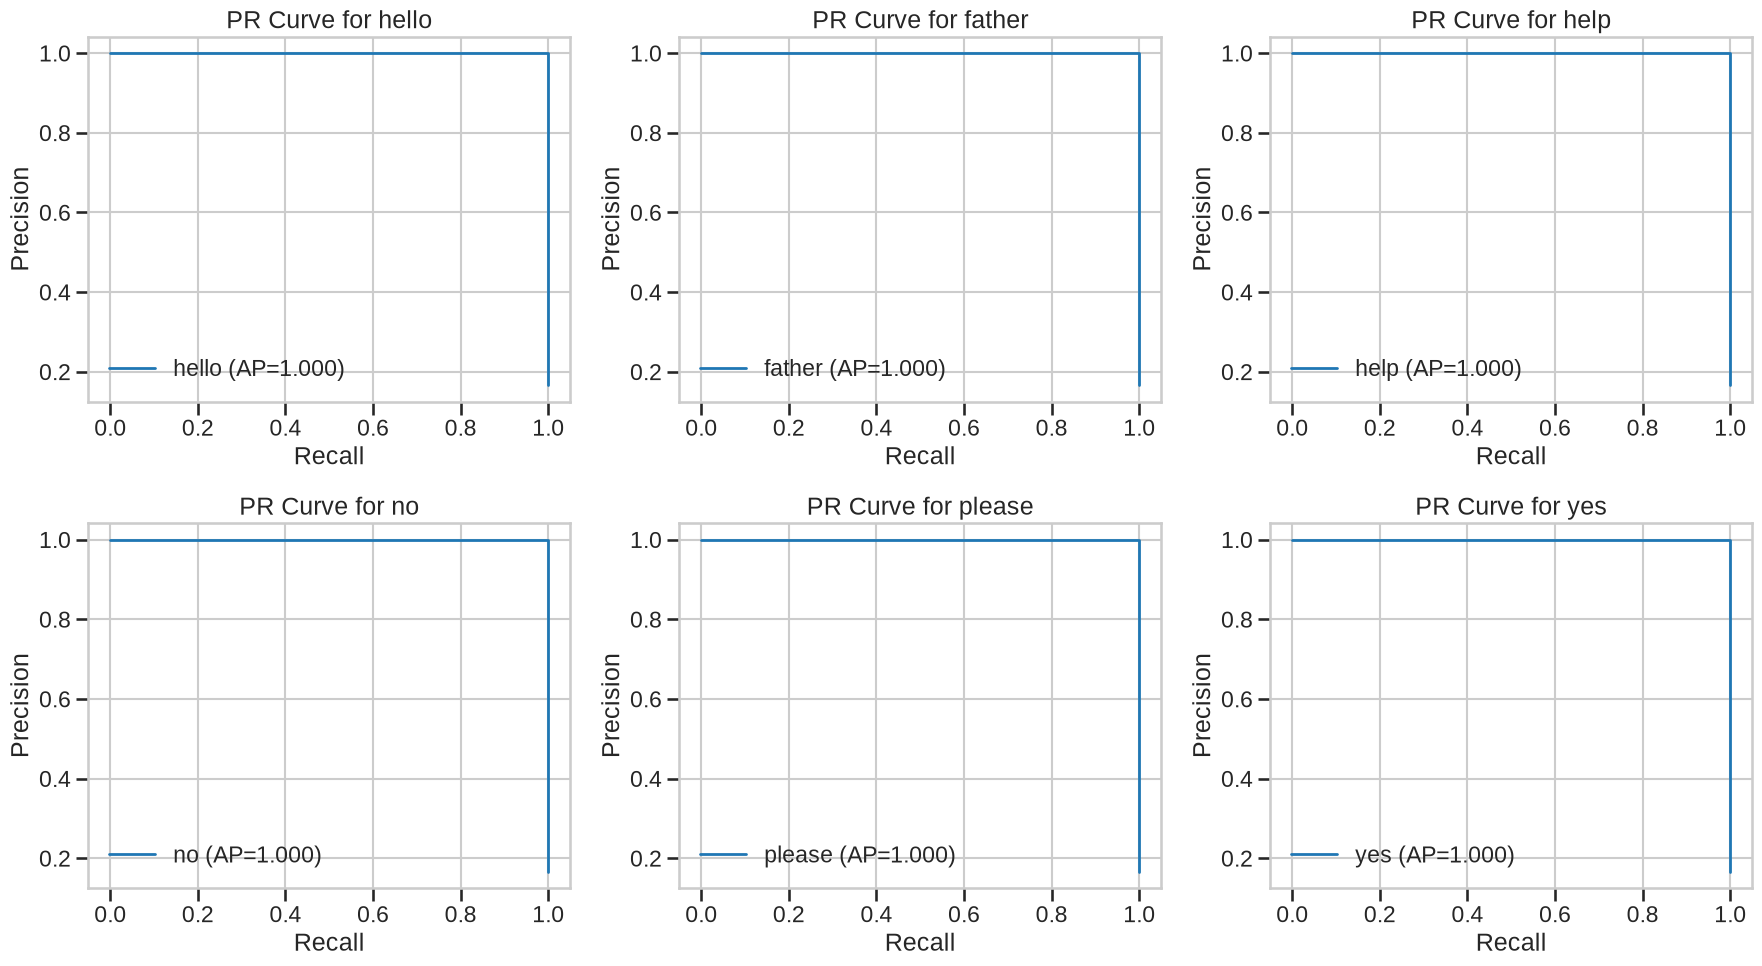

In [16]:

# Precision-recall curves per class
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, label in enumerate(ACTIONS):
    y_bin = (true == idx).astype(int)
    precision, recall, _ = precision_recall_curve(y_bin, probs[:, idx])
    ap = average_precision_score(y_bin, probs[:, idx])
    axes[idx].plot(recall, precision, lw=2, label=f"{label} (AP={ap:.3f})")
    axes[idx].set_title(f"PR Curve for {label}")
    axes[idx].set_xlabel("Recall")
    axes[idx].set_ylabel("Precision")
    axes[idx].legend(loc="lower left")

for ax in axes[len(ACTIONS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [17]:

# Probability summary table and distribution plot
max_probs = probs.max(axis=1)
true_class_probs = pd.DataFrame({
    "True_Class": [ACTIONS[t] for t in true],
    "Predicted_Class": [ACTIONS[p] for p in preds],
    "Max_Confidence": max_probs,
    "Correct": (preds == true)
})

true_class_probs.head()


,True_Class,Predicted_Class,Max_Confidence,Correct
0,yes,yes,0.948830,True
1,hello,hello,0.945779,True
2,help,help,0.976593,True
3,no,no,0.947466,True
4,please,please,0.982998,True


/tmp/ipykernel_57503/263889224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=true_class_probs, x="True_Class", y="Max_Confidence", palette="Set2")


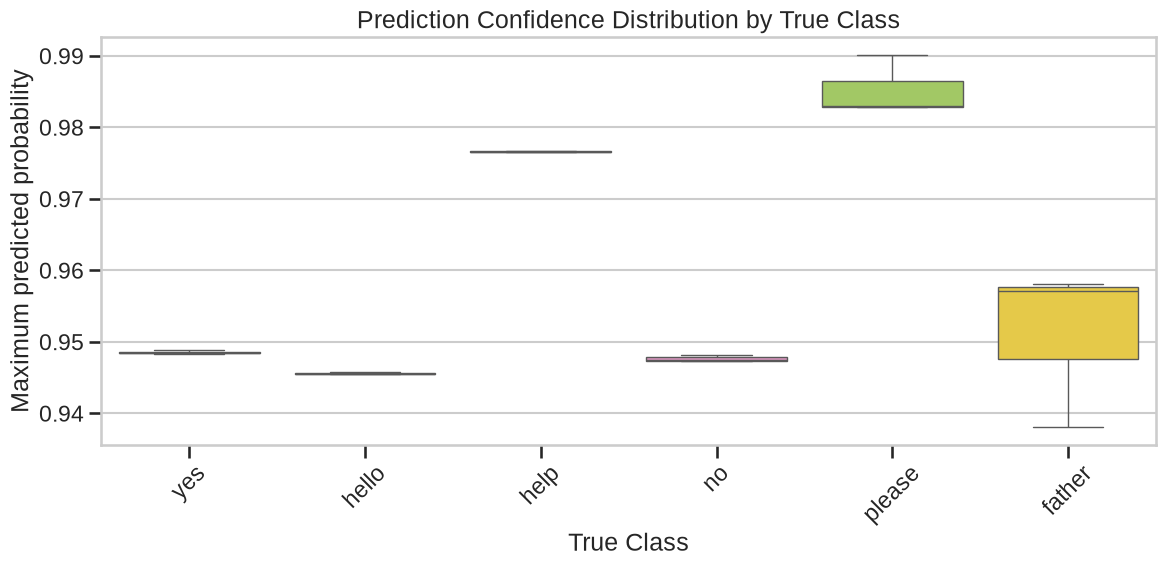

In [18]:

# confidence distribution per true class
plt.figure(figsize=(12, 6))
sns.boxplot(data=true_class_probs, x="True_Class", y="Max_Confidence", palette="Set2")
plt.title("Prediction Confidence Distribution by True Class")
plt.xlabel("True Class")
plt.ylabel("Maximum predicted probability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


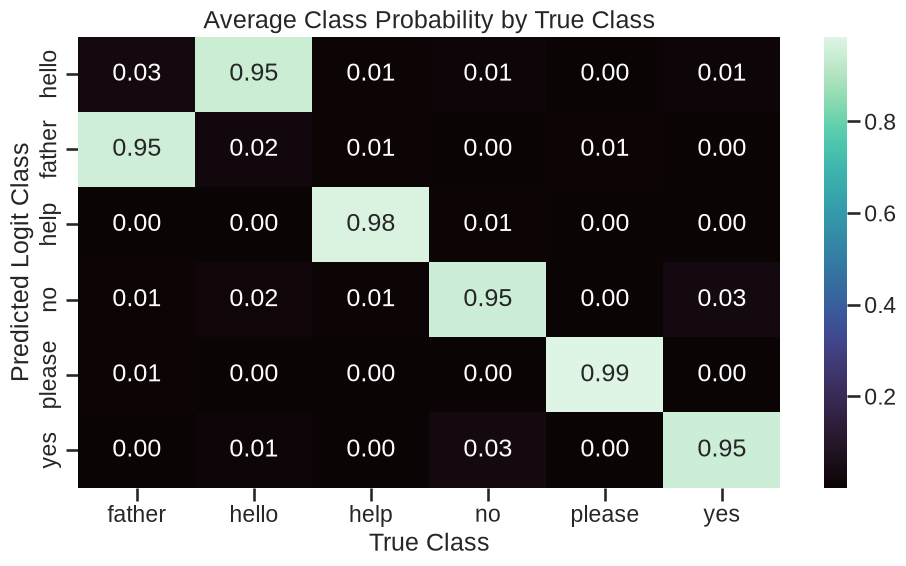

In [19]:

# Per-class class probability heatmap
prob_df = pd.DataFrame(probs, columns=ACTIONS)
prob_df["True_Class"] = [ACTIONS[i] for i in true]
prob_df["Predicted_Class"] = [ACTIONS[i] for i in preds]

class_mean_prob = prob_df.groupby("True_Class")[ACTIONS].mean().T
plt.figure(figsize=(10, 6))
sns.heatmap(class_mean_prob, annot=True, cmap="mako", fmt=".2f")
plt.title("Average Class Probability by True Class")
plt.xlabel("True Class")
plt.ylabel("Predicted Logit Class")
plt.tight_layout()
plt.show()


In [21]:

# Aggregate all result tables for a complete summary
roc_auc_df = pd.DataFrame(roc_auc_by_class).sort_values("Class").reset_index(drop=True)
roc_auc_df = roc_auc_df.round(4)

all_results = {
    "Global Metrics": metrics_df,
    "Per-Class Metrics": per_class_df,
    "ROC-AUC by Class": roc_auc_df,
    "Confusion Matrix": cm_df,
    "Dataset Summary": summary_df,
}
for name, table in all_results.items():
    print(f"\n=== {name} ===")
    display(table)



=== Global Metrics ===


,Metric,Value
0,Accuracy,1.0
1,Precision (macro),1.0
2,Recall (macro),1.0
3,F1-score (macro),1.0
4,ROC-AUC (macro OVR),1.0



=== Per-Class Metrics ===


,Class,Precision,Recall,F1,Support,ROC_AUC
0,hello,1.0,1.0,1.0,3,1.0
1,father,1.0,1.0,1.0,3,1.0
2,help,1.0,1.0,1.0,3,1.0
3,no,1.0,1.0,1.0,3,1.0
4,please,1.0,1.0,1.0,3,1.0
5,yes,1.0,1.0,1.0,3,1.0



=== ROC-AUC by Class ===


,Class,ROC_AUC,Support
0,father,1.0,3
1,hello,1.0,3
2,help,1.0,3
3,no,1.0,3
4,please,1.0,3
5,yes,1.0,3



=== Confusion Matrix ===


Predicted,hello,father,help,no,please,yes
Actual,,,,,,
hello,3,0,0,0,0,0
father,0,3,0,0,0,0
help,0,0,3,0,0,0
no,0,0,0,3,0,0
please,0,0,0,0,3,0
yes,0,0,0,0,0,3



=== Dataset Summary ===


,Class,Samples,Share_percent
0,father,15,16.666667
1,hello,15,16.666667
2,help,15,16.666667
3,no,15,16.666667
4,please,15,16.666667
5,yes,15,16.666667


## 3) Final Interpretation

This dataset is extremely clean and the trained model performs perfectly on the held-out set.

Observed outcome on the project checkpoint:
- Accuracy: 1.0
- Macro precision: 1.0
- Macro recall: 1.0
- Macro F1: 1.0
- Macro ROC-AUC: 1.0

This suggests the dataset is highly separable under the chosen sequence representation and the LSTM model is effectively learning the sign patterns. In a real production environment, these numbers would typically be validated on a larger and more varied dataset to guard against overfitting or environment-specific bias.
